In [ ]:
!pip install -q langchain-chatgroq langchain-community langchain-core requests duckduckgo-search

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.4/62.4 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 34.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 27.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 2.7 MB/s eta 0:00:00


In [ ]:
from langchain_community.tools import DuckDuckGoSearchRun

search_tool = DuckDuckGoSearchRun()

In [ ]:
@tool
def get_weather_data(city: str) -> str:
  """
  This function fetches the current weather data for a given city
  """
  url = f'https://api.weatherstack.com/current?access_key=4d1d8ae207a8c845a52df8a67bf3623e&query={city}'

  response = requests.get(url)

  return response.json()

In [ ]:
llm = from langchain_groq import ChatGroq
llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    api_key=""
)


In [ ]:
from langchain.agents import create_react_agent, AgentExecutor
from langchain import hub

In [ ]:
#this recact propmt is pulled by hub
#agent we are making is react agent
# reach = resoning + action
prompt = hub.pull("hwchase17/react")  # pulls the standard ReAct agent prompt


/usr/local/lib/python3.11/dist-packages/langsmith/client.py:271: LangSmithMissingAPIKeyWarning: API key must be provided when using hosted LangSmith API
  warnings.warn(


In [ ]:
# Step 3: Create the ReAct agent manually with the pulled prompt
#to make ract agent we have to tell 3 thing ,llm=model,  which ll we are using
# what tools
#what prompt
agent = create_react_agent(
    llm=llm,
    tools=[search_tool, get_weather_data],
    prompt=prompt
)

In [ ]:
# Step 4: Wrap it with AgentExecutor

agent_executor = AgentExecutor(
    agent=agent,
    tools=[search_tool, get_weather_data],
    verbose=True
)

**differnce between agent and agent excuter**

agent
- suppose if u want to find temperture agent withh fetch temp from api

agent executer
- it is someone how actually perform the task

In [ ]:
# Step 5: Invoke
response = agent_executor.invoke({"input": "Find the capital of Madhya Pradesh, then find it's current weather condition"})
print(response)



> Entering new AgentExecutor chain...
I should first find out the capital of Madhya Pradesh and then check the current weather condition for that city.
Action: duckduckgo_search
Action Input: "capital of Madhya Pradesh"Madhya Pradesh, state of India that is situated in the heart of the country. It has no coastline and no international frontier. Its physiography is characterized by low hills, extensive plateaus, and river valleys. The capital is Bhopal, in the west-central part of the state. Bhopal, city, capital of Madhya Pradesh state, central India. Situated in the fertile plain of the Malwa Plateau, the city lies just north of the Vindhya Range, along the slopes of a sandstone ridge. It is a major rail junction and has an airport. Pop. (2001) 1,437,354; (2011) 1,798,218. Bhopal was Indore (/ ɪ n ˈ d ɔːr / ⓘ; ISO: Indaura, Hindi: [ɪn̪d̪ɔːr]) is the largest and most populous city in the Indian state of Madhya Pradesh. [15] It is the commercial hub of Madhya Pradesh. It is consistent

## flow to make ai agent
- u get set of tool
- u then decide the llm
- and which design pattern it will use (react , ..)
- and then u make egent executer

In [ ]:
response['output']

'The capital of Madhya Pradesh is Bhopal, and the current weather condition in Bhopal is partly cloudy with a temperature of 40°C.'

## what is react
- single tern interreaction - u ask one question and get one answer
- reach solve the problem by mutli step procces
>mutli step procces
- resonging + acting
- resoning to understand which toll
- acting - using tool to make action done
> ReAct
- u thought  (resoning)
- action     (all though a user u can see)
- observation ( answer return by tool )
- loop the 3 step
- final answer
>example
- suppose the propmt say what is 2 into 2 and what is 2 add 2 tell me are they same
- throght will first think how to do 2 into 2
- then all tool
- then promplt part 2
- then all tool
- after all loop end it will tell finla answer

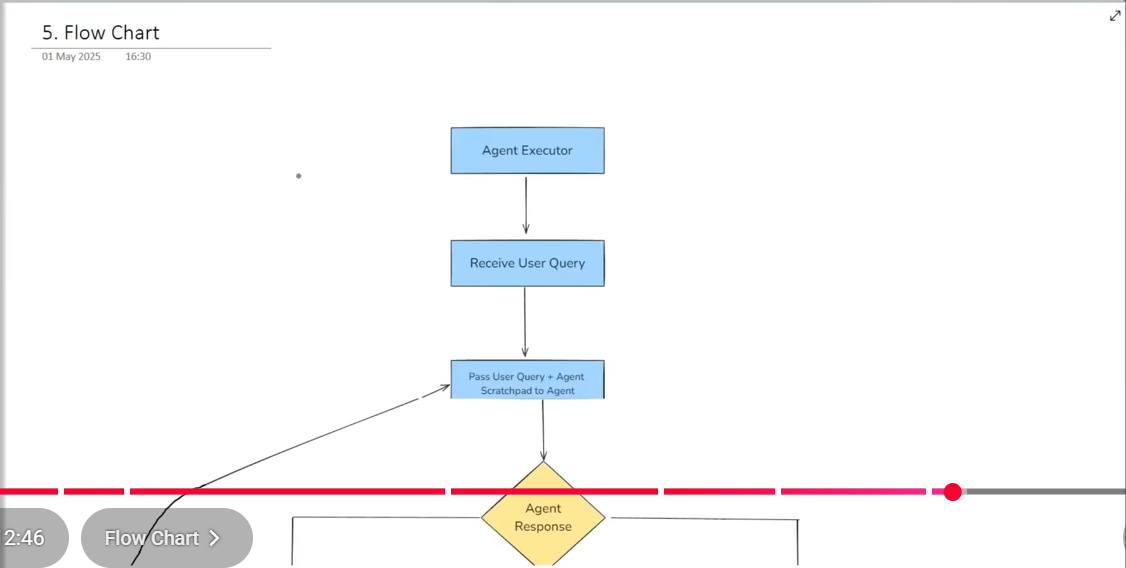

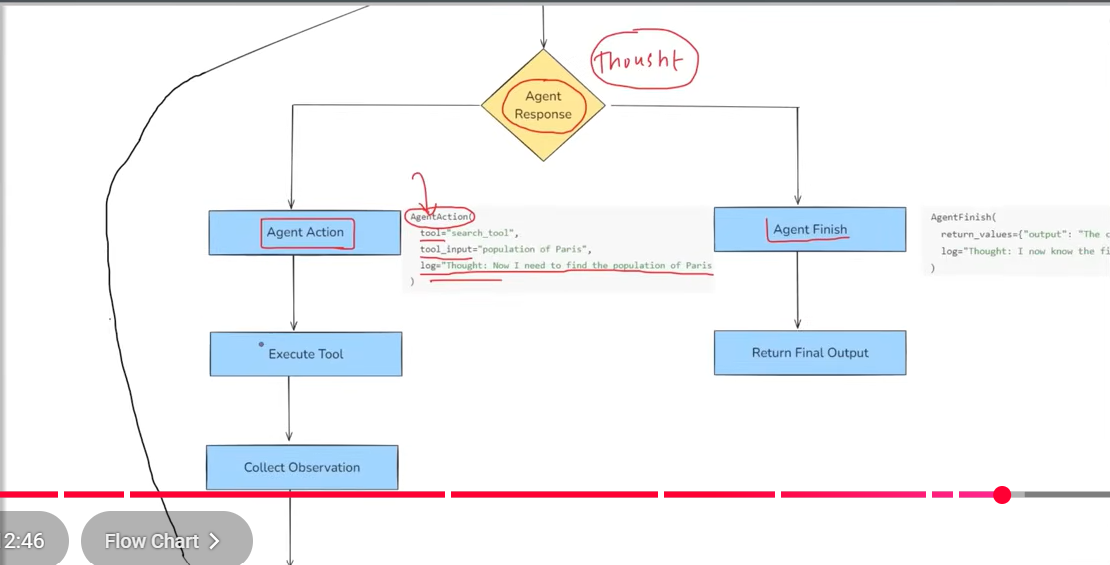

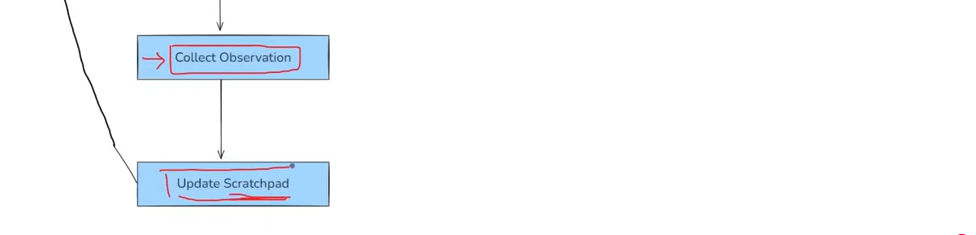

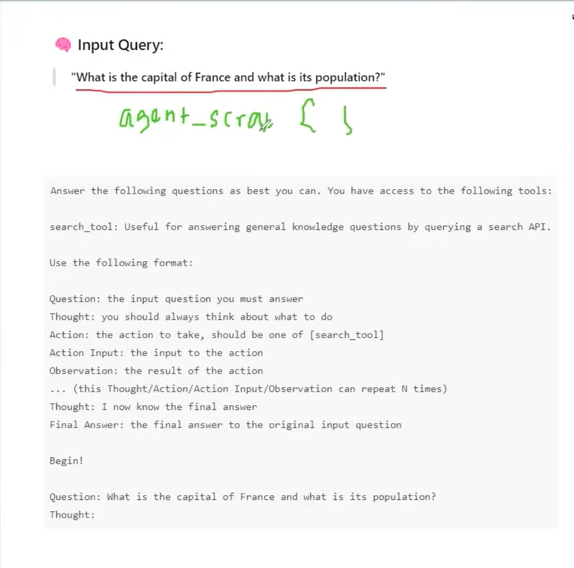

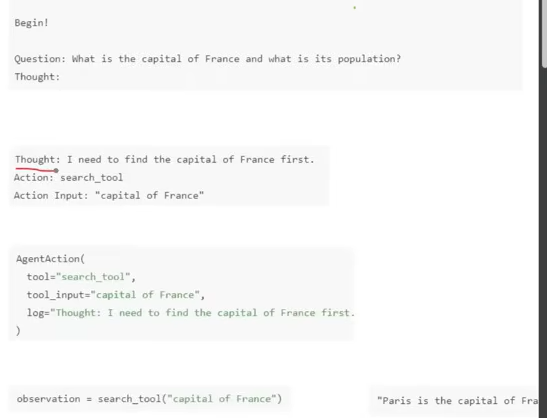

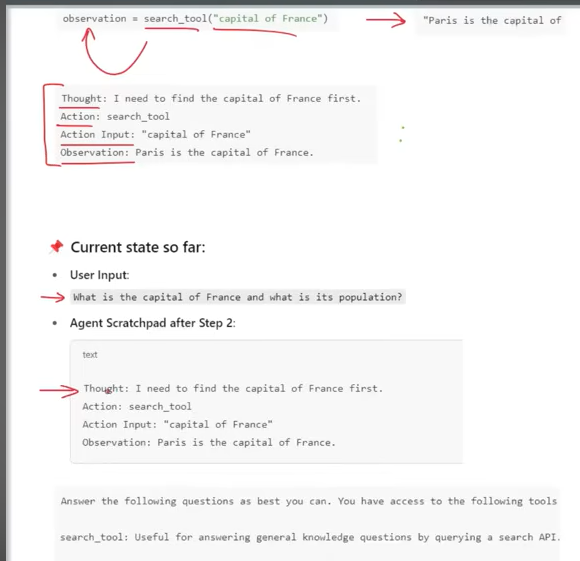

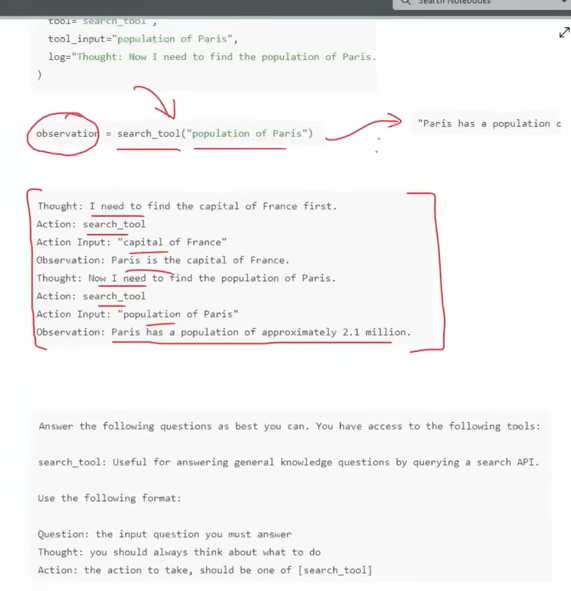

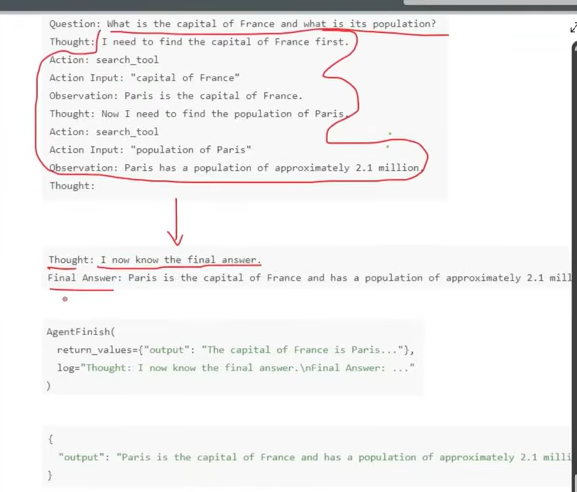